In [1]:
import numpy as np
import json, os 
import torch
import torch.utils.data as data
import cv2

In [2]:
class_list = os.listdir('./data/train')
matcher = {k:i for i, k in enumerate(class_list)}
with open('class_map.json', 'w') as f:
    json.dump(matcher, f, indent=4)
print(matcher)


{'Andesite': 0, 'Basalt': 1, 'Etc': 2, 'Gneiss': 3, 'Granite': 4, 'Mud_Sandstone': 5, 'Weathered_Rock': 6}


In [ ]:
from rock_25_04.module.dataset import CustomDataset

In [4]:
dataset =CustomDataset('./data/train',matcher=matcher)

KeyboardInterrupt: 

In [ ]:
len(dataset), dataset[0][0].shape, dataset[0][1]

NotImplementedError: Subclasses of Dataset should implement __getitem__.

In [ ]:
shape_list = []
for i in range(len(dataset)):
    shape_list.append(dataset[i][0].shape)
shape_list = np.array(shape_list)
print(max(shape_list[:, 0]), max(shape_list[:, 1]))
print(min(shape_list[:, 0]), min(shape_list[:, 1]))

1076 1102
28 1


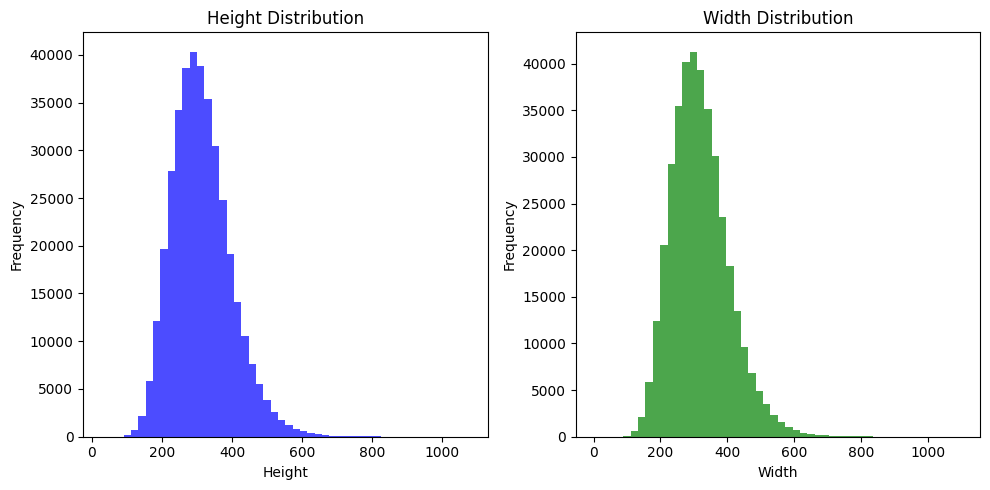

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
datashape_df = pd.DataFrame(shape_list, columns=['height', 'width', 'channel'])
datashape_df.to_csv('datashape.csv', index=False)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].hist(datashape_df['height'], bins=50, color='blue', alpha=0.7)
axes[0].set_title('Height Distribution')
axes[0].set_xlabel('Height')
axes[0].set_ylabel('Frequency')

axes[1].hist(datashape_df['width'], bins=50, color='green', alpha=0.7)
axes[1].set_title('Width Distribution')
axes[1].set_xlabel('Width')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
mean_height, mean_width = shape_list[:, 0].mean(), shape_list[:, 1].mean()
std_height, std_width = shape_list[:, 0].std(), shape_list[:, 1].std()

print(f"Mean Height: {round(mean_height)}, Mean Width: {round(mean_width)}")
print(f"Std Height: {round(std_height)}, Std Width: {round(std_width)}")

Mean Height: 314, Mean Width: 319
Std Height: 84, Std Width: 86


In [ ]:
# Extract top 10 heights
top_10_heights = datashape_df.nlargest(10, 'height')
print("Top 10 Heights:")
print(top_10_heights)

# Extract bottom 10 heights
bottom_10_heights = datashape_df.nsmallest(10, 'height')
print("\nBottom 10 Heights:")
print(bottom_10_heights)

# Extract top 10 widths
top_10_widths = datashape_df.nlargest(10, 'width')
print("\nTop 10 Widths:")
print(top_10_widths)

# Extract bottom 10 widths
bottom_10_widths = datashape_df.nsmallest(10, 'width')
print("\nBottom 10 Widths:")
print(bottom_10_widths)

Top 10 Heights:
        height  width  channel
163421    1076    485        3
163167    1068    478        3
333834    1044    335        3
163728    1001    731        3
163370     987    519        3
163821     981    601        3
347546     959    372        3
163685     955    606        3
347308     953    392        3
347937     950    378        3

Bottom 10 Heights:
        height  width  channel
85179       28     23        3
85181       28     23        3
322151      32      1        3
73958       34     32        3
321822      75    350        3
321825      76    351        3
49288       78    201        3
255244      82    186        3
255248      82    186        3
343118      82     85        3

Top 10 Widths:
        height  width  channel
163163     414   1102        3
163374     602   1070        3
163378     602   1070        3
163723     848   1024        3
162910     531    996        3
163366     519    987        3
163816     601    981        3
377148     337    

In [ ]:
for i in range(20):
    img, label = dataset[i]
    print(f"Image shape: {img.shape}, Label: {label}")

Image shape: (409, 292, 3), Label: 0
Image shape: (459, 441, 3), Label: 0
Image shape: (455, 499, 3), Label: 0
Image shape: (319, 446, 3), Label: 0
Image shape: (292, 409, 3), Label: 0
Image shape: (441, 459, 3), Label: 0
Image shape: (455, 499, 3), Label: 0
Image shape: (329, 458, 3), Label: 0
Image shape: (446, 319, 3), Label: 0
Image shape: (501, 351, 3), Label: 0
Image shape: (422, 466, 3), Label: 0
Image shape: (320, 415, 3), Label: 0
Image shape: (501, 351, 3), Label: 0
Image shape: (422, 466, 3), Label: 0
Image shape: (334, 555, 3), Label: 0
Image shape: (415, 320, 3), Label: 0
Image shape: (326, 382, 3), Label: 0
Image shape: (386, 327, 3), Label: 0
Image shape: (382, 326, 3), Label: 0
Image shape: (386, 327, 3), Label: 0


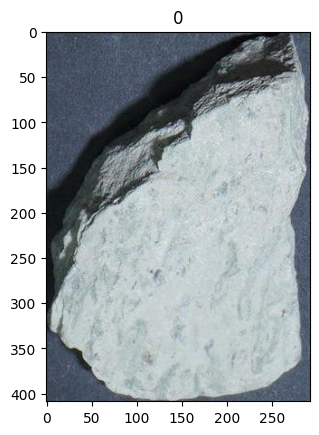

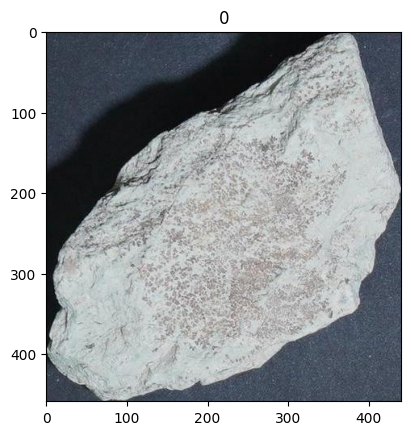

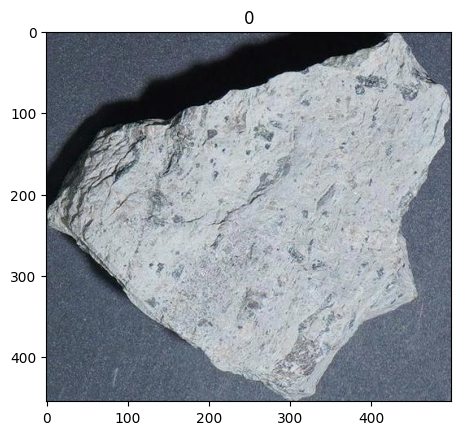

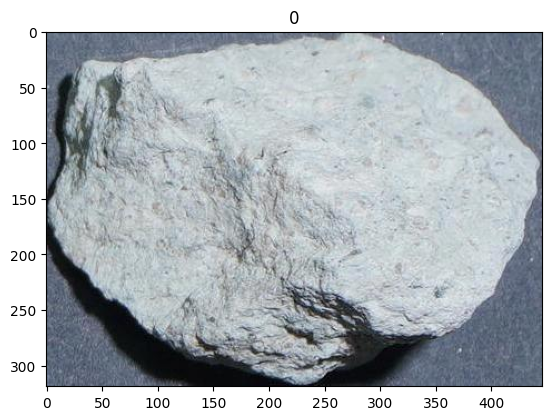

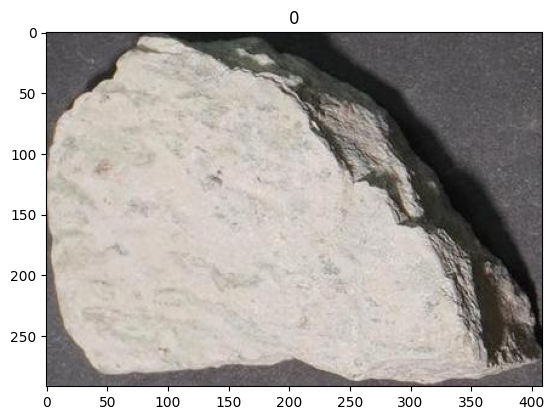

In [ ]:
import matplotlib.pyplot as plt
for i in range(5):
    img, label = dataset[i]
    plt.imshow(img)
    plt.title(label)
    plt.show()



In [ ]:
from rock_25_04.module.resizing import get_resize_thresholds, CustomRockResize

params = get_resize_thresholds(384)
transform = CustomRockResize(
    resize_size=384,
    resize_thresh=params['resize_thresh'],
    min_size=params['min_size']
)


In [ ]:
new_dataset = CustomDataset('./data/train', matcher=matcher,transform=transform,filter_invalid=True)
print(len(dataset), len(new_dataset))

380020 379681


In [ ]:
len(new_dataset)-len(dataset)

-339

In [ ]:
len(new_dataset.data), len(new_dataset.labels)

(379681, 379681)

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
counter = Counter(new_dataset.labels)
counter

Counter({np.int64(4): 92847,
         np.int64(5): 89403,
         np.int64(3): 73885,
         np.int64(0): 43799,
         np.int64(6): 37144,
         np.int64(1): 26675,
         np.int64(2): 15928})

In [ ]:
import os
import numpy as np
import cv2
import torch
from rock_25_04.module.dataset import DualTransformDataset
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split

# ✅ 클래스 라벨 매핑
label_dict = {
    'Andesite': 0,
    'Basalt': 1,
    'Etc': 2,
    'Gneiss': 3,
    'Granite': 4,
    'Mud_Sandstone': 5,
    'Weathered_Rock': 6
}

# ✅ 일반 클래스용 transform
def default_transform(img, resize_size=384):
    img = cv2.resize(img, (resize_size, resize_size))
    if np.random.rand() < 0.5:
        img = cv2.flip(img, 1)
    return img

# ✅ Etc 클래스 전용 transform
def strong_transform_for_etc(img, resize_size=384):
    img = cv2.resize(img, (resize_size, resize_size))
    if np.random.rand() < 0.5:
        img = cv2.flip(img, 1)
    if np.random.rand() < 0.3:
        img = cv2.flip(img, 0)
    if np.random.rand() < 0.4:
        img = cv2.GaussianBlur(img, (3, 3), sigmaX=0)
    if np.random.rand() < 0.4:
        noise = np.random.normal(0, 10, img.shape).astype(np.float32)
        img = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)
    return img

# ✅ Etc인지 판별하는 조건 함수
def is_etc(class_name):
    return class_name.lower() == "etc"

# ✅ Dataset 정의 (DualTransformDataset 클래스는 이미 위에서 정의한 것 사용)
dataset = DualTransformDataset(
    data_path="./data/train",  # 이미지 경로: ./data/train/<클래스명>/*.jpg
    matcher=label_dict,
    default_transform=default_transform,
    custom_transform=strong_transform_for_etc,
    use_custom_condition_fn=is_etc,
    filter_invalid=True
)


# ✅ Stratified Split with Subset
indices = np.arange(len(dataset))
train_idx, val_idx = train_test_split(
    indices,
    test_size=0.2,
    stratify=dataset.labels,
    random_state=42
)

train_set = Subset(dataset, train_idx)
val_set = Subset(dataset, val_idx)

# ✅ DataLoader 정의
train_loader = DataLoader(train_set, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False, num_workers=0)

# ✅ 확인
print(f"Train: {len(train_set)} samples, Val: {len(val_set)} samples")


Train: 304016 samples, Val: 76004 samples
